# Ad hoc covariate exploration


## Load

In [ ]:
from pathlib import Path
import os
import subprocess
import sys

# Bootstrap scripts/ from $WORKSPACE_BUCKET/scripts/ when not on the VM.
for _d in (Path.cwd() / "scripts", Path.cwd().parent / "scripts"):
    if (_d / "terra_notebook.py").is_file():
        sys.path.insert(0, str(_d.resolve()))
        break
else:
    _bucket = os.environ.get("WORKSPACE_BUCKET", "").rstrip("/")
    if not _bucket:
        raise FileNotFoundError(
            "scripts/ not found locally and WORKSPACE_BUCKET is unset. "
            "Upload scripts/ to gs://WORKSPACE/scripts/."
        )
    _dest = (Path.cwd() / "scripts").resolve()
    _dest.mkdir(parents=True, exist_ok=True)
    subprocess.check_call(
        ["gsutil", "-m", "rsync", "-r", f"{_bucket}/scripts/", str(_dest) + "/"]
    )
    sys.path.insert(0, str(_dest))

from __future__ import annotations

from terra_notebook import init_notebook

SCRIPTS = init_notebook("workspace_paths.py")
from workspace_paths import data_root

import sys

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

pd.set_option("display.max_columns", 80)
pd.set_option("display.max_rows", 80)
pd.set_option("display.width", 140)
sns.set_theme(style="whitegrid", context="notebook")

ROOT = data_root()
COV_CSV = ROOT / "covariates.source_rebuilt.csv.gz"
COV_DICT = ROOT / "covariates.source_rebuilt.data_dictionary.tsv"
print("ROOT:", ROOT)
print("CSV:", COV_CSV)


In [2]:
BOOL_COLS = [
    "lr_meet_qc", "lr_releasable_v9", "rna_meet_qc", "has_rna",
    "proteomics_meet_qc", "has_proteomics", "has_exposomics", "has_srWGS",
    "has_demographics", "has_extraction_method", "has_trgt",
    "has_global_pcs", "has_pop_pcs", "in_cdr_v7", "in_cdr_v8", "in_cdr_v9",
    "has_methylation", "in_phenotype_table", "is_AIAN", "withdrawn",
    "unavailable", "final_releasable_v9", "in_final_set", "has_lr_tech",
    "has_ONT", "has_PacBio", "has_ancestry_annotation", "in_pedigree",
    "pedigree_is_founder", "has_sv_counts",
]

df = pd.read_csv(
    COV_CSV,
    dtype={"research_id": str, "biobank_id": str, "zip3": str},
    low_memory=False,
)
dictionary = pd.read_csv(COV_DICT, sep="\t")

for c in BOOL_COLS:
    if c not in df.columns:
        continue
    df[c] = df[c].fillna(False).astype(bool)
if "has_ehr_data" in df.columns:
    df["has_ehr_data"] = df["has_ehr_data"].map(
        {True: True, False: False, "True": True, "False": False}
    )

print(f"{len(df):,} rows × {df.shape[1]} columns")
print("unique research_id:", df["research_id"].nunique(), "is_unique:", df["research_id"].is_unique)
df.head()

17,226 rows × 130 columns
unique research_id: 17226 is_unique: True


,research_id,lr_phase,lr_meet_qc,lr_releasable_v9,rna_meet_qc,has_rna,proteomics_meet_qc,has_proteomics,has_exposomics,has_srWGS,age,sex_at_birth,zip3,has_ehr_data,has_demographics,extraction_method,has_extraction_method,has_trgt,n_trgt_vcfs,population,ancestry_pred,ancestry_pred_other,has_ancestry_annotation,in_pedigree,pedigree_family_id,pedigree_is_founder,pedigree_n_parents,pedigree_family_size,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9,PC10,PC11,PC12,...,pop_PC31,pop_PC32,has_global_pcs,has_pop_pcs,in_cdr_v7,in_cdr_v8,in_cdr_v9,has_methylation,in_phenotype_table,biobank_id,GC,technology,platform,pb_meth_caller,inferred_sex,coverage,coverage_source,ont_coverage,ont_aligned_num_bases,ont_aligned_num_reads,ont_read_length_n50,ont_read_length_mean,ont_read_length_median,ont_read_length_stdev,ont_average_identity,ont_median_identity,has_sv_counts,n_sv_del,n_sv_ins,is_AIAN,withdrawn,unavailable,final_releasable_v9,in_final_set,n_final_rows,has_lr_tech,has_ONT,has_PacBio,n_lr_technical_rows,techs_available
0,1000151,phase_1,True,True,False,False,False,False,False,True,60.0,Female,301**,True,True,Chemagen,True,False,0,AFR,afr,afr,True,False,NaN,False,NaN,NaN,-0.321940,-0.016134,-0.001288,-0.002408,0.001091,-0.003034,-0.006677,0.002063,0.000331,0.002098,0.002281,0.001405,...,0.008920,-0.012538,True,True,True,True,True,False,False,A915293704,HA,PacBio,Sequel,none,NaN,7.761223,integratedcall_phase1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False,7815.0,11053.0,False,False,False,False,False,0,False,False,False,1.0,PacBio
1,1000234,phase_2,True,True,False,False,True,True,True,True,90.0,Male,100**,True,True,Chemagen,True,True,1,OTH,eur,eur,True,False,NaN,False,NaN,NaN,0.073913,-0.031621,-0.009257,0.121840,0.037207,0.005074,-0.034906,0.008358,-0.006816,0.010277,-0.002356,0.003420,...,0.002262,-0.004464,True,True,False,True,True,True,True,A817169780,BI,PacBio,Revio,primrose-1.4.0,XY,13.050000,v9_technical,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,True,10192.0,16609.0,False,False,False,True,True,1,True,False,True,1.0,PacBio
2,1000291,phase_2,True,True,True,True,True,True,False,True,62.0,Female,100**,True,True,Chemagen,True,True,1,AMR,amr,amr,True,False,NaN,False,NaN,NaN,0.044508,0.010864,0.017751,0.020062,0.015277,-0.013339,0.068728,-0.007511,0.014327,0.041801,-0.009175,0.034051,...,0.019911,-0.001136,True,True,False,False,True,True,True,A318292205,BI,PacBio,Revio,primrose-1.4.0,XX,16.940000,v9_technical,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,True,10540.0,17611.0,False,False,False,True,True,1,True,False,True,1.0,PacBio
3,1000513,phase_1,True,True,False,False,False,False,False,True,77.0,Female,602**,True,True,Chemagen,True,False,0,AFR,afr,afr,True,False,NaN,False,NaN,NaN,-0.253890,-0.019336,-0.003178,-0.007917,-0.000202,0.001264,-0.001573,0.002242,-0.000765,0.003227,-0.001089,0.003201,...,0.011788,0.002408,True,True,True,True,True,False,False,A236725162,HA,PacBio,Sequel,none,NaN,6.934806,integratedcall_phase1,34.81,1.036050e+11,6140280.0,21197.0,17496.1,16283.0,9754.4,96.9,98.7,False,7500.0,10603.0,False,False,False,False,False,0,False,True,False,1.0,ONT|PacBio
4,1000610,phase_2,True,True,True,True,True,True,False,True,55.0,Male,701**,False,True,Chemagen,True,True,1,EUR,eur,eur,True,False,NaN,False,NaN,NaN,0.089074,-0.039391,-0.001687,-0.004663,0.007436,-0.001470,0.012316,0.005503,0.006546,-0.004843,0.001461,-0.000872,...,0.002291,0.000205,True,True,False,False,True,True,True,A839749970,BI,PacBio,Revio,jasmine-2.2.0,XY,17.310000,v9_technical,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,True,10315.0,17401.0,False,False,False,True,True,1,True,False,True,1.0,PacBio


## Helpers

- `colinfo("has_rna")` — dictionary note + value counts / describe
- `lookup("1234567")` — one person, transposed
- `releasable` — `final_releasable_v9` subset

In [3]:
def colinfo(name: str, data: pd.DataFrame | None = None) -> None:
    """Print dictionary text and a compact summary for one column."""
    data = df if data is None else data
    hit = dictionary.loc[dictionary["column"] == name]
    if hit.empty:
        print(f"{name}: not in data dictionary")
    else:
        row = hit.iloc[0]
        print(f"{name}")
        print(f"  source: {row['source']}")
        print(f"  notes:  {row['notes']}")
    if name not in data.columns:
        print("  (column missing from table)")
        return
    s = data[name]
    print(f"  dtype:  {s.dtype}   non-null: {s.notna().mean():.1%} ({s.notna().sum():,}/{len(s):,})")
    if pd.api.types.is_bool_dtype(s):
        print(s.value_counts(dropna=False).to_string())
    elif pd.api.types.is_numeric_dtype(s) and s.nunique(dropna=True) > 12:
        print(s.describe().to_string())
    else:
        print(s.value_counts(dropna=False).head(20).to_string())


def lookup(research_id: str, data: pd.DataFrame | None = None) -> pd.DataFrame:
    """Return one row, transposed, for a research_id."""
    data = df if data is None else data
    rid = str(research_id)
    hit = data.loc[data["research_id"] == rid]
    if hit.empty:
        raise KeyError(f"research_id {rid} not in table")
    return hit.T.rename(columns={hit.index[0]: rid})


releasable = df.loc[df["final_releasable_v9"]].copy()
print(f"releasable v9: {len(releasable):,} / {len(df):,}")

releasable v9: 13,530 / 17,226


## Schema

In [4]:
dictionary

,column,source,notes
0,research_id,multiomics research_id,primary key
1,lr_phase,multiomics long_read phase,phase_1 / phase_2 / phase_1_phase_2
2,lr_meet_qc,multiomics long_read meet QC,bool; blank→False
3,lr_releasable_v9,multiomics long_read releasable v9,bool; blank→False
4,rna_meet_qc,multiomics RNASeq meet QC,bool; blank→False
...,...,...,...
125,has_lr_tech,derived,in ONT∪PacBio v9 sheets
126,has_ONT,ONT_v9 (+ Phase 1 curated ONT list),True if in CDRv9 ONT sheet or curated Phase 1 ...
127,has_PacBio,PacBio_v9,True if present in CDRv9 PacBio lrWGS sheet
128,n_lr_technical_rows,final_set (+ Phase 1 fill),number of long-read technical source rows befo...


In [5]:
pd.DataFrame({
    "column": df.columns,
    "dtype": [str(t) for t in df.dtypes],
    "n_missing": df.isna().sum().to_numpy(),
    "n_unique": [df[c].nunique(dropna=True) for c in df.columns],
})

,column,dtype,n_missing,n_unique
0,research_id,str,0,17226
1,lr_phase,str,2551,3
2,lr_meet_qc,bool,0,2
3,lr_releasable_v9,bool,0,2
4,rna_meet_qc,bool,0,2
...,...,...,...,...
125,has_lr_tech,bool,0,2
126,has_ONT,bool,0,2
127,has_PacBio,bool,0,2
128,n_lr_technical_rows,float64,2683,3


## Cohort flags

In [6]:
flags = [
    "in_final_set", "final_releasable_v9", "has_lr_tech", "withdrawn", "unavailable",
    "in_cdr_v7", "in_cdr_v8", "in_cdr_v9",
    "has_PacBio", "has_ONT", "has_methylation", "has_trgt",
    "has_rna", "has_proteomics", "has_exposomics", "has_ehr_data",
    "in_phenotype_table", "has_srWGS",
]
rows = []
for c in flags:
    s = df[c]
    if c == "has_ehr_data":
        n_true = int(s.fillna(False).astype(bool).sum())
        n_na = int(s.isna().sum())
    else:
        n_true = int(s.sum())
        n_na = 0
    rows.append({"flag": c, "n_true": n_true, "n_na": n_na, "frac": n_true / len(df)})
pd.DataFrame(rows)

,flag,n_true,n_na,frac
0,in_final_set,13662,0,0.793103
1,final_releasable_v9,13530,0,0.785441
2,has_lr_tech,13530,0,0.785441
3,withdrawn,123,0,0.007140
4,unavailable,9,0,0.000522
5,in_cdr_v7,1027,0,0.059619
6,in_cdr_v8,2800,0,0.162545
7,in_cdr_v9,14521,0,0.842970
8,has_PacBio,12261,0,0.711773
9,has_ONT,2194,0,0.127366


## Technology, platform, center

In [7]:
for col in ["lr_phase", "technology", "techs_available", "platform", "GC", "extraction_method"]:
    print(f"\n--- {col} ---")
    print(df[col].fillna("NA").value_counts().to_string())


--- lr_phase ---
lr_phase
phase_2            13648
NA                  2551
phase_1             1013
phase_1_phase_2       14

--- technology ---
technology
PacBio    13274
NA         2683
ONT        1269

--- techs_available ---
techs_available
PacBio        12349
NA             2683
ONT            1269
ONT|PacBio      925

--- platform ---
platform
Revio          11044
NA              2683
Sequel          2230
ONT-R10.4.1     1269

--- GC ---
GC
BI     9910
NA     2683
HA     2219
BCM    1307
JHU     710
UW      397

--- extraction_method ---
extraction_method
Chemagen    11268
Autogen      3293
NA           2665


In [8]:
print("among releasable v9")
pd.crosstab(
    releasable["technology"].fillna("NA"),
    releasable["has_ONT"],
    margins=True,
)

among releasable v9


has_ONT,False,True,All
technology,,,
ONT,0,1269,1269
PacBio,11385,876,12261
All,11385,2145,13530


## Ancestry and demographics

In [9]:
print("population (PCA training set)")
print(df["population"].fillna("NA").value_counts().to_string())
print("\nancestry_pred")
print(df["ancestry_pred"].fillna("NA").value_counts().to_string())
print("\nsex_at_birth")
print(df["sex_at_birth"].fillna("NA").value_counts().to_string())
df["age"].describe()

population (PCA training set)
population
AFR    4199
AMR    3573
OTH    3311
EUR    2857
EAS    1395
SAS    1252
MID     442
NA      197

ancestry_pred
ancestry_pred
afr    5091
eur    4316
amr    4181
sas    1455
eas    1435
mid     517
NA      231

sex_at_birth
sex_at_birth
Female                                      9504
Male                                        6981
PMI: Skip                                    428
NA                                           128
I prefer not to answer                       114
Sex At Birth: Sex At Birth None Of These      43
Intersex                                      28


count    17077.000000
mean        53.708848
std         16.927197
min         21.000000
25%         39.000000
50%         55.000000
75%         67.000000
max         90.000000
Name: age, dtype: float64

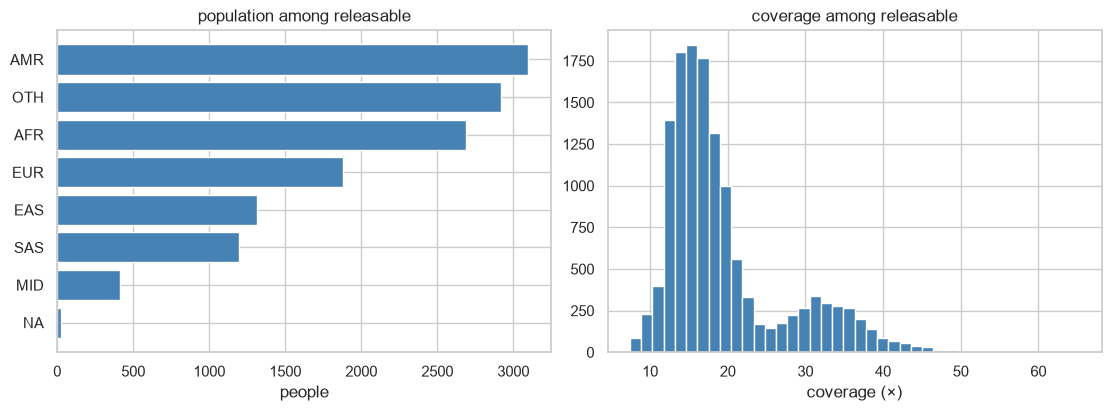

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4), constrained_layout=True)
pop = releasable["population"].fillna("NA").value_counts()
axes[0].barh(pop.index[::-1], pop.values[::-1], color="steelblue")
axes[0].set_title("population among releasable")
axes[0].set_xlabel("people")
axes[1].hist(releasable["coverage"].dropna(), bins=40, color="steelblue")
axes[1].set_title("coverage among releasable")
axes[1].set_xlabel("coverage (×)")
plt.show()

## Scratch

In [11]:
# Examples:
# colinfo("withdrawn")
# lookup(df["research_id"].iloc[0])
# releasable.query("has_ONT and technology == 'PacBio'")[["research_id", "coverage", "platform", "GC"]]

colinfo("has_ONT")

has_ONT
  source: ONT_v9 (+ Phase 1 curated ONT list)
  notes:  True if in CDRv9 ONT sheet or curated Phase 1 additional-ONT research IDs
  dtype:  bool   non-null: 100.0% (17,226/17,226)
has_ONT
False    15032
True      2194
